In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

np.random.seed(42)

## 1. Data Preprocessing

In [2]:
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
data_path = 'heart+disease/processed.cleveland.data'
df = pd.read_csv(data_path, names=columns, na_values='?')

df = df.dropna()

# Binary classification: 0 -> No Disease (0), 1-4 -> Disease (1)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop(columns=['num'])

categorical_features = ['cp', 'restecg', 'slope', 'thal']
continuous_features = ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

X = df.drop(columns=['target'])
y = df['target'].values

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (237, 18)
Testing shape: (60, 18)


## 2. RBF Network Construction

In [ ]:
class RBFNetwork:
    def __init__(self, k, sigma=1.0, learning_rate=0.01, epochs=100):
        self.k = k
        self.sigma = sigma
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.centers = None
        self.weights = None
        self.bias = None

    def _rbf_kernel(self, X, center):
        distance = np.linalg.norm(X - center, axis=1)
        return np.exp(- (distance ** 2) / (2 * self.sigma ** 2))

    def fit(self, X, y):
        kmeans = KMeans(n_clusters=self.k, random_state=42, n_init=10)
        kmeans.fit(X)
        self.centers = kmeans.cluster_centers_

        self.weights = np.random.randn(self.k)
        self.bias = np.random.randn()

        # 2. Train using SGD
        for epoch in range(self.epochs):
            for i in range(X.shape[0]):
                # Forward pass for single sample
                xi = X[i].reshape(1, -1)
                phi = np.array([self._rbf_kernel(xi, c)[0] for c in self.centers])
                linear_output = np.dot(phi, self.weights) + self.bias
                
                # Sigmoid activation for binary classification
                prediction = 1 / (1 + np.exp(-linear_output))
                
                error = y[i] - prediction
                
                self.weights += self.learning_rate * error * prediction * (1 - prediction) * phi
                self.bias += self.learning_rate * error * prediction * (1 - prediction)

    def predict_proba(self, X):
        phi_matrix = np.zeros((X.shape[0], self.k))
        for j in range(self.k):
            phi_matrix[:, j] = self._rbf_kernel(X, self.centers[j])
        
        linear_output = np.dot(phi_matrix, self.weights) + self.bias
        return 1 / (1 + np.exp(-linear_output))

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return (probabilities >= 0.5).astype(int)

## 3. Experimentation and Evaluation

Training RBF Network with k=3, sigma=0.5...


/home/chloycosta/Documents/College_code/Sem_5/NNDL/.venv/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.6000, F1-Score: 0.0000
Training RBF Network with k=3, sigma=1.0...
Accuracy: 0.6333, F1-Score: 0.2143
Training RBF Network with k=3, sigma=2.0...
Accuracy: 0.8500, F1-Score: 0.7907
Training RBF Network with k=3, sigma=5.0...
Accuracy: 0.7500, F1-Score: 0.5714
Training RBF Network with k=5, sigma=0.5...


/home/chloycosta/Documents/College_code/Sem_5/NNDL/.venv/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.6000, F1-Score: 0.0000
Training RBF Network with k=5, sigma=1.0...
Accuracy: 0.6333, F1-Score: 0.2143
Confusion Matrix:
 [[35  1]
 [21  3]]


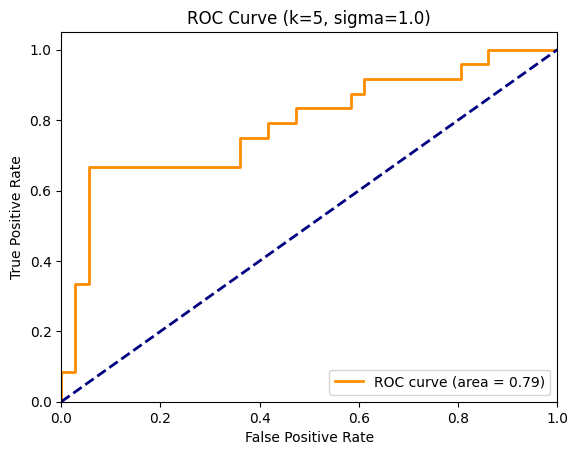

Training RBF Network with k=5, sigma=2.0...
Accuracy: 0.8333, F1-Score: 0.7727
Training RBF Network with k=5, sigma=5.0...
Accuracy: 0.7500, F1-Score: 0.5946
Training RBF Network with k=7, sigma=0.5...


/home/chloycosta/Documents/College_code/Sem_5/NNDL/.venv/lib64/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.6000, F1-Score: 0.0000
Training RBF Network with k=7, sigma=1.0...
Accuracy: 0.6333, F1-Score: 0.2143
Training RBF Network with k=7, sigma=2.0...
Accuracy: 0.8333, F1-Score: 0.7727
Training RBF Network with k=7, sigma=5.0...
Accuracy: 0.7667, F1-Score: 0.6316

Experiment Results:
    k  sigma  accuracy  precision    recall        f1
0   3    0.5  0.600000   0.000000  0.000000  0.000000
1   3    1.0  0.633333   0.750000  0.125000  0.214286
2   3    2.0  0.850000   0.894737  0.708333  0.790698
3   3    5.0  0.750000   0.909091  0.416667  0.571429
4   5    0.5  0.600000   0.000000  0.000000  0.000000
5   5    1.0  0.633333   0.750000  0.125000  0.214286
6   5    2.0  0.833333   0.850000  0.708333  0.772727
7   5    5.0  0.750000   0.846154  0.458333  0.594595
8   7    0.5  0.600000   0.000000  0.000000  0.000000
9   7    1.0  0.633333   0.750000  0.125000  0.214286
10  7    2.0  0.833333   0.850000  0.708333  0.772727
11  7    5.0  0.766667   0.857143  0.500000  0.631579


In [ ]:
k_values = [3, 5, 7]
sigma_values = [0.5, 1.0, 2.0, 5.0]

results = []

for k in k_values:
    for sigma in sigma_values:
        print(f"Training RBF Network with k={k}, sigma={sigma}...")
        rbf = RBFNetwork(k=k, sigma=sigma, learning_rate=0.1, epochs=50)
        rbf.fit(X_train, y_train)
        
        y_pred = rbf.predict(X_test)
        y_prob = rbf.predict_proba(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            'k': k,
            'sigma': sigma,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1
        })
        
        print(f"Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")
        
        if k == 5 and sigma == 1.0:
            cm = confusion_matrix(y_test, y_pred)
            print("Confusion Matrix:\n", cm)
            
            # ROC Curve
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(fpr, tpr)
            
            plt.figure()
            plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC Curve (k={k}, sigma={sigma})')
            plt.legend(loc="lower right")
            plt.show()

results_df = pd.DataFrame(results)
print("\nExperiment Results:")
print(results_df)

### 1. Underfitting Scenario
* **Parameters:** `sigma = 0.5` (observed across k=3, 5, 7)
* **Accuracy:** Stuck at `0.6000` (Baseline/Majority Class).
* **F1-Score:** `0.0000`.
* **Warning:** "Precision is ill-defined... no predicted samples."

The spread ($\sigma$) is **too narrow**. The RBF neurons (Gaussian kernels) act like tiny spikes and only respond to data points extremely close to the centers. Most data points fall in the "dead zones" between centers where there is zero activation. The model fails to learn any pattern and simply predicts the majority class (Class 0) for everyone.

### 2. Optimal Fit Scenario (The Sweet Spot)
* **Parameters:** `sigma = 2.0` (Best performance seen at k=3 and k=7)
* **Accuracy:** Peaks at `0.8500`.
* **F1-Score:** High values around `0.79`.

The spread is **just right**. The kernels are wide enough to cover the local clusters of data points formed by K-Means, but narrow enough to preserve the decision boundary between "Disease" and "No Disease."

### 3. Over-smoothing Scenario (Performance Degradation)
* **Parameters:** `sigma = 5.0`
* **Accuracy:** Drops to `0.7500` - `0.7667`.
* **F1-Score:** Drops significantly to `0.57` - `0.63`.

The spread is **too wide**. The Gaussian kernels flatten out and overlap significantly. This blurs the distinction between the classes (over-smoothing), causing the model to lose discrimination power and make more errors compared to the optimal setting.